2026-05-04 19:53:24.819114: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-04 19:53:34.927965: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 5, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 5, 10)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 5, 64),   │     19,200 │ input_layer[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 5, 64),   │     19,200 │ input_layer_1[0]… │
│                     │ (None, 64),       │            │ lstm[0][1],       │
│                     │ (None, 64)]       │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 5, 64)     │          0 │ lstm_1[0][0],     │
│ (Attention)         │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 5, 128)    │          0 │ lstm_1[0][0],     │
│ (Concatenate)       │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5, 10)     │      1,290 │ concatenate[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 39,690 (155.04 KB)

 Trainable params: 39,690 (155.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.3033 - loss: 2.0682 - val_accuracy: 0.3454 - val_loss: 1.6780
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3649 - loss: 1.5600 - val_accuracy: 0.3736 - val_loss: 1.4904
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3884 - loss: 1.4312 - val_accuracy: 0.4068 - val_loss: 1.3844
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4483 - loss: 1.3019 - val_accuracy: 0.4908 - val_loss: 1.2259
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5322 - loss: 1.1128 - val_accuracy: 0.5772 - val_loss: 1.0199
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step


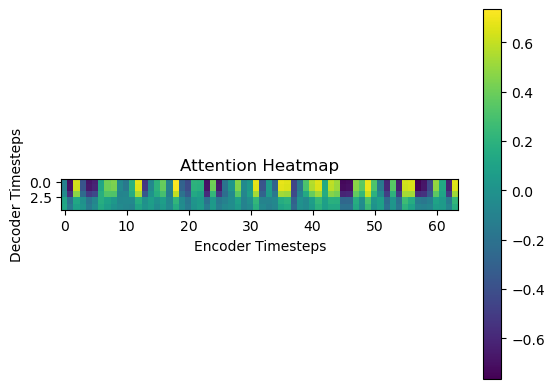

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, LSTM, Dense, Attention
from tensorflow.keras.models import Model

# -----------------------------
# 1. Seed
# -----------------------------
np.random.seed(42)
tf.random.set_seed(42)

# -----------------------------
# 2. Dummy Data (reverse task)
# -----------------------------
num_samples = 5000
max_len = 5
vocab_size = 10

X = np.random.randint(1, vocab_size, size=(num_samples, max_len))
y = np.flip(X, axis=1)

X = tf.keras.utils.to_categorical(X, num_classes=vocab_size)
y = tf.keras.utils.to_categorical(y, num_classes=vocab_size)

# -----------------------------
# 3. Encoder
# -----------------------------
encoder_inputs = Input(shape=(max_len, vocab_size))
encoder_lstm = LSTM(64, return_sequences=True, return_state=True)

encoder_outputs, state_h, state_c = encoder_lstm(encoder_inputs)

# -----------------------------
# 4. Decoder
# -----------------------------
decoder_inputs = Input(shape=(max_len, vocab_size))
decoder_lstm = LSTM(64, return_sequences=True, return_state=True)

decoder_outputs, _, _ = decoder_lstm(
    decoder_inputs,
    initial_state=[state_h, state_c]
)

# -----------------------------
# 5. Attention Layer
# -----------------------------
attention_layer = Attention()
attention_output = attention_layer([decoder_outputs, encoder_outputs])

# Combine
concat = tf.keras.layers.Concatenate()([decoder_outputs, attention_output])

# Final output
decoder_dense = Dense(vocab_size, activation='softmax')
outputs = decoder_dense(concat)

# -----------------------------
# 6. Model
# -----------------------------
model = Model([encoder_inputs, decoder_inputs], outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# -----------------------------
# 7. Train
# -----------------------------
history = model.fit(
    [X, X],
    y,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# -----------------------------
# 8. Get Attention Weights
# -----------------------------
attention_model = Model(
    inputs=model.input,
    outputs=attention_output
)

# Test sample
sample = X[:1]
attention_weights = attention_model.predict([sample, sample])

# -----------------------------
# 9. Heatmap Visualization
# -----------------------------
plt.imshow(attention_weights[0], cmap='viridis')
plt.colorbar()
plt.title("Attention Heatmap")
plt.xlabel("Encoder Timesteps")
plt.ylabel("Decoder Timesteps")
plt.show()